In [31]:
library(Seurat)
library(harmony)
library(spacexr)

library(ggplot2)
library(ggplotify)
library(ggsci)
library(scatterpie)
library(patchwork)

library(ComplexHeatmap)
library(grid)
library(circlize)

library(Matrix)
library(dplyr)

source('../R_function/ST_plot.R')
source('../R_function/mutimodal.R')
source('../R_function/knn_function.R')
source('../R_function/calculate_function.R')
source('../R_function/MultiSpecies.R')

In [32]:
packageVersion('spacexr')

[1] ‘2.2.1’

In [4]:
use_type <- c('Upper-IT_Pr','Middle-IT_Pr','Deep-IT_Pr','Deep-CT_Pr','Deep-PT_Pr',
              'Upper-IT_Al','Middle-IT_Al','Deep-IT_Al','Deep-CT_Al','Deep-PT_Al','Deep-NP_Al','Deep-RGS12_Al',
              'MGE.PVALB_Pr','MGE.PVALB-POSTN_Pr','MGE.SST_Pr','LGE.TSHZ1_Pr','LGE.FOXP1_Pr',
              'MGE.SST_Al','CGE.VIP_Al','CGE.LAMP5_Al','CGE.LAMP5-PRKG1_Al','CGE.LAMP5-RELN_Al','CGE.RELN_Al')

In [5]:
Class_color <- c('#F0E685FF','#CE3D32FF','#5DB1DDFF','#466983FF',
                 '#5050FFFF','#837B8DFF','#BA6338FF','#802268FF','#6BD76BFF','#D595A7FF','#924822FF','#749B58FF')
names(Class_color) <- c('GLU','CGE','MGE','LGE',
                        'AST','EPC','MG','NB','OLG','OPC','VLMC','EC')

Archr_col <- c('#D51F26','#272E6A','#208A42','#89288F','#F47D2B','#FEE500','#8A9FD1',
               '#C06CAB','#E6C2DC','#90D5E4','#89C75F','#F37B7D','#9983BD','#D24B27',
               '#3BBCA8','#6E4B9E','#0C727C','#7E1416','#D8A767')
Subclass_color <- c(Archr_col[1:17],
                    '#5050FFFF','#837B8DFF','#BA6338FF','#802268FF','#6BD76BFF','#D595A7FF','#924822FF','#749B58FF')
names(Subclass_color) <- c('MGE.PVALB','MGE.PVALB-POSTN','MGE.SST','CGE.VIP','CGE.LAMP5','CGE.LAMP5-PRKG1','CGE.LAMP5-RELN','CGE.RELN','LGE.TSHZ1','LGE.FOXP1',
                           'Upper-IT','Middle-IT','Deep-IT','Deep-CT','Deep-PT','Deep-NP','Deep-RGS12',
                           'AST','EPC','MG','NB','OLG','OPC','VLMC','EC')

Species_color <- c('#2A6EBBFF','#F0AB00FF','#C50084FF','#7D5CC6FF','#E37222FF','#69BE28FF','#00B2A9FF')
names(Species_color) <- c('marm','mous','bird','turt','axol','lung','lamp')

In [70]:
obj_merge <- readRDS('Analysis/obj_merge_final.rds')
obj_IN <- readRDS('Analysis/obj_GABA_integrated_final.rds')
obj_EX <- readRDS('Analysis/obj_GLU_integrated_final.rds')

In [96]:
rm(obj_merge)
rm(obj_IN)
rm(obj_EX)
gc()

Warning message in rm(obj_merge):
“object 'obj_merge' not found”
Warning message in rm(obj_IN):
“object 'obj_IN' not found”
Warning message in rm(obj_EX):
“object 'obj_EX' not found”


,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,5918608,316.1,9807271,523.8,9807271,523.8
Vcells,2284812229,17431.8,10106153808,77103.9,11334946097,86478.8


<font size=16>Analysis<font size=16>

In [27]:
obj_celltype_all <- readRDS('Analysis/RCTD/obj_celltype_all.rds')
names(obj_celltype_all)[names(obj_celltype_all)=='moum_T313'] <- 'mous_T313'
tmp_names <- names(obj_celltype_all)
obj_celltype_all <- lapply(tmp_names,function(x){
    obj_tmp <- obj_celltype_all[[x]]
    #obj_tmp[['celltype']] <- CreateAssayObject(data=obj_tmp[['celltype']]$data[grepl('LGE|MGE|CGE|Upper|Middle|Deep',rownames(obj_tmp[['celltype']])),])
    obj_tmp@assays$celltype@counts <- obj_tmp@assays$celltype@data
    obj_tmp$sample <- x
    return(obj_tmp)
})
names(obj_celltype_all) <- tmp_names

In [28]:
for(i in c('marm_T454','mous_T313','bird_a1','bird_d4','bird_a5','turt_a2','turt_f5','axol_all','lung_all')){
    RCTD_tmp_ST <- readRDS(paste0('/mnt/gandan/huangzhi/jupyter/Multispecies/Analysis/RCTD/RCTD_',i,'_Neuron_result.rds'))
    interset_cell <- colnames(obj_celltype_all[[i]])
    interset_cell <- interset_cell[interset_cell%in%rownames(RCTD_tmp_ST@results$weights)]
    obj_celltype_all[[i]] <- obj_celltype_all[[i]][,interset_cell]
    obj_celltype_all[[i]][['celltype']] <- CreateAssayObject(data=Matrix::t(RCTD_tmp_ST@results$weights[interset_cell,]))
    obj_celltype_all[[i]][['celltype']]$counts <- obj_celltype_all[[i]][['celltype']]$data
}

Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Layer counts isn't present in the assay object; returning NULL”
Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Layer counts isn't present in the assay object; returning NULL”
Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Layer counts isn't present in the assay object; returning NULL”
Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Layer counts isn't present in the assay object; returning NULL”
Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Layer counts isn't present in the assay object; returning NULL”
Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Layer counts isn't p

In [29]:
#add bird mask
bird_mask1 <- read_real_mask_plot('Plot/Region_mask/bird_S1_mask_-205.73_-41.08.tif',x_offset = -205.73, y_offset = -41.08)
bird_mask2 <- read_real_mask_plot('Plot/Region_mask/bird_S2_mask_-287.59_-98.79.tif',x_offset = -287.59, y_offset = -98.79)
bird_mask3 <- read_real_mask_plot('Plot/Region_mask/bird_S3_mask_-156.73_-191.17.tif',x_offset = -156.73, y_offset = -191.17)
bird_mask1$region <- c('255'='H','210'='L','205'='E','200'='IH','100'='N','150'='M')[as.character(bird_mask1$mask)]
bird_mask2$region <- c('255'='H','210'='L','205'='E','200'='IH','100'='N','150'='M')[as.character(bird_mask2$mask)]
bird_mask3$region <- c('255'='H','210'='L','205'='E','200'='IH','100'='N','150'='M')[as.character(bird_mask3$mask)]
obj_celltype_all[['bird_a1']]@meta.data <- df_add_mask(obj_celltype_all[['bird_a1']]@meta.data,bird_mask1,imputation = T,mask_col = 'region')
obj_celltype_all[['bird_d4']]@meta.data <- df_add_mask(obj_celltype_all[['bird_d4']]@meta.data,bird_mask2,imputation = T,mask_col = 'region')
obj_celltype_all[['bird_a5']]@meta.data <- df_add_mask(obj_celltype_all[['bird_a5']]@meta.data,bird_mask3,imputation = T,mask_col = 'region')

#add turt mask
turt_mask1 <- read_real_mask_plot('Plot/Region_mask/turt_A2_mask_-141.92_49.7.tif',x_offset = -141.92, y_offset = 49.7)
turt_mask2 <- read_real_mask_plot('Plot/Region_mask/turt_F5_mask_-24.54_-92.43.tif',x_offset = -24.54, y_offset = -92.43)
turt_mask1$region <- c('255'='aDVR','200'='LC','150'='lDC','100'='PT','50'='mDC')[as.character(turt_mask1$mask)]
turt_mask2$region <- c('255'='aDVR','200'='LC','150'='lDC','100'='PT','50'='mDC')[as.character(turt_mask2$mask)]
obj_celltype_all[['turt_a2']]@meta.data <- df_add_mask(obj_celltype_all[['turt_a2']]@meta.data,turt_mask1,imputation = T,mask_col = 'region')
obj_celltype_all[['turt_f5']]@meta.data <- df_add_mask(obj_celltype_all[['turt_f5']]@meta.data,turt_mask2,imputation = T,mask_col = 'region')

lung_mask <- read_real_mask_plot('Plot/Region_mask/lung_all_mask_-132.73_-551.34.tif',x_offset = -132.73, y_offset = -551.34)
lung_mask$region <- c('255'='Ms','200'='MP','150'='DP','100'='LP','75'='LA')[as.character(lung_mask$mask)]
obj_celltype_all[['lung_all']]@meta.data <- df_add_mask(obj_celltype_all[['lung_all']]@meta.data,lung_mask,imputation = T,mask_col = 'region')


axol_mask <- read_real_mask_plot('Plot/Region_mask/axol_all_mask_-247.34_-19.36.tif',x_offset = -247.34, y_offset = -19.36)
axol_mask$region <- c('255'='MP','200'='DP','150'='LP','100'='LA')[as.character(axol_mask$mask)]
obj_celltype_all[['axol_all']]@meta.data <- df_add_mask(obj_celltype_all[['axol_all']]@meta.data,axol_mask,imputation = T,mask_col = 'region')

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


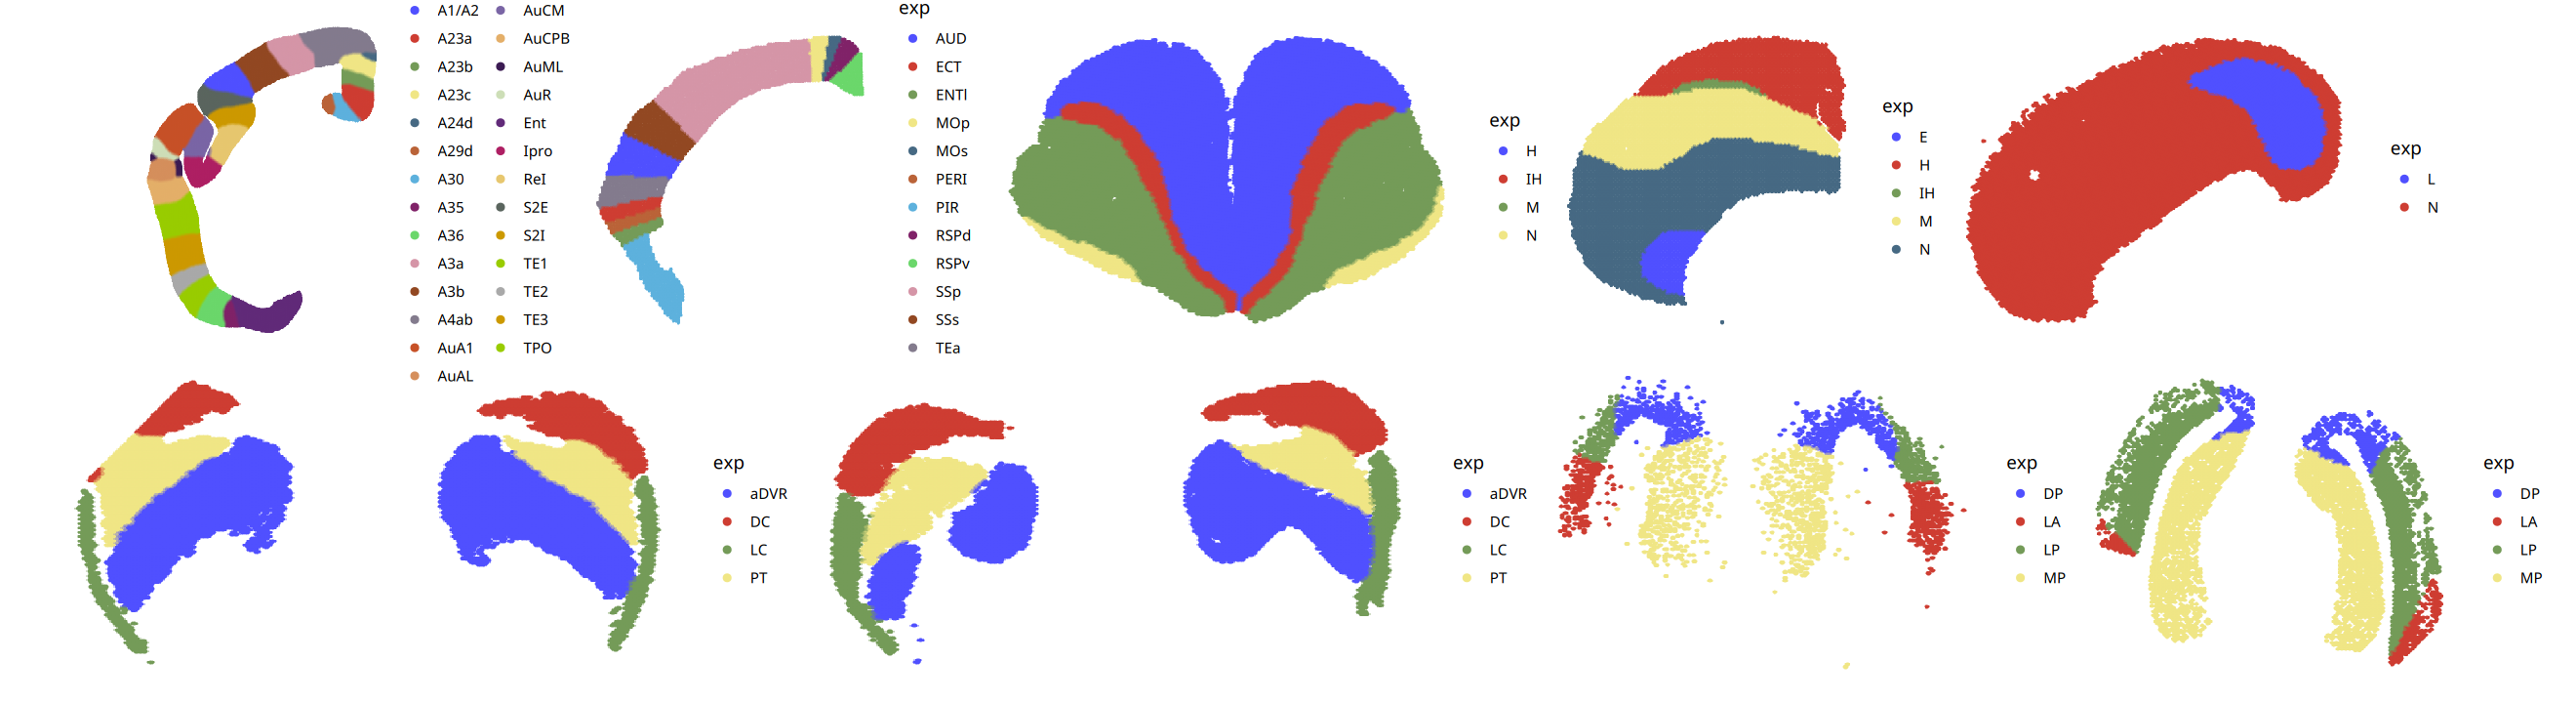

In [612]:
#obj_celltype_all_merge$subset_region <- 'Other'
#obj_celltype_all_merge@meta.data[obj_celltype_all_merge$PrAl_celltype>= 0.25,'subset_region'] <- 'Pr'
#obj_celltype_all_merge@meta.data[obj_celltype_all_merge$PrAl_celltype<= -0.25,'subset_region'] <- 'Al'
#use_color <- rev(c("#f94144","#f3722c","#f8961e","#f9844a","#f9c74f","#90be6d","#43aa8b","#4d908e","#577590","#277da1"))
#use_color <- c("#3d348b","#7678ed","#f7b801","#f18701","#f35b04")
#limits=c(-1,1)
p1 <- 
plot_spatial_col(obj_celltype_all[['marm_T454']]@meta.data,col_name = 'region',smooth = F, size = 3.5)+scale_color_manual(values  = pal_igv()(50))+
plot_spatial_col(obj_celltype_all[['mous_T313']]@meta.data,col_name = 'region',smooth = F, size = 3.5)+scale_color_manual(values  = pal_igv()(50))+
plot_spatial_col(obj_celltype_all[['bird_a1']]@meta.data,  col_name = 'region',smooth = F, size = 3.5)+scale_color_manual(values  = pal_igv()(50))+
plot_spatial_col(obj_celltype_all[['bird_d4']]@meta.data,  col_name = 'region',smooth = F, size = 3.5)+scale_color_manual(values  = pal_igv()(50))+
plot_spatial_col(obj_celltype_all[['bird_a5']]@meta.data,  col_name = 'region',smooth = F, size = 3.5)+scale_color_manual(values  = pal_igv()(50))+
plot_layout(ncol = 5)

p2 <- 
plot_spatial_col(obj_celltype_all[['turt_a2']]@meta.data,  col_name = 'region',smooth = F, size = 3.5)+scale_color_manual(values  = pal_igv()(50))+
plot_spatial_col(obj_celltype_all[['turt_f5']]@meta.data,  col_name = 'region',smooth = F, size = 3.5)+scale_color_manual(values  = pal_igv()(50))+
plot_spatial_col(obj_celltype_all[['axol_all']]@meta.data, col_name = 'region',smooth = F, size = 3.5)+scale_color_manual(values  = pal_igv()(50))+
plot_spatial_col(obj_celltype_all[['lung_all']]@meta.data, col_name = 'region',smooth = F, size = 3.5)+scale_color_manual(values  = pal_igv()(50))+
plot_layout(ncol = 4)
options(repr.plot.width=22,repr.plot.height=6)
p1/p2

In [30]:
obj_celltype_all_raw <- obj_celltype_all

In [11]:
source('../R_function/calculate_function.R')

In [880]:
for(i in names(obj_celltype_all)){
    obj_tmp <- obj_celltype_all[[i]]
    species <- gsub('_.*','',i)
    plot_celltype <- rownames(obj_tmp)
    celltype_score <- as.numeric(gsub("minus", "-",gsub(".*-", "",gsub(".*--", "minus", rownames(obj_tmp)))))
    for(j in 1:length(plot_celltype)){
        if(celltype_score[j]>0){
            p <- plot_spatial_feature(obj_tmp,features = plot_celltype[j],col=c('gray','#a10034'),smooth = T, size = 3.5,slot='data',assays = 'celltype')
        }else{
            p <- plot_spatial_feature(obj_tmp,features = plot_celltype[j],col=c('gray','#0061b3'),smooth = T, size = 3.5,slot='data',assays = 'celltype')
        }
        save_png_plot(p,'Plot/celltype_location/',paste0(plot_celltype[j],'-',i),height=800,width=600,save='ggsave')
    }
}

Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; returning the first one. To return all, use `return_all = TRUE`.”


NULL


Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; returning the first one. To return all, use `return_all = TRUE`.”


NULL


Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; returning the first one. To return all, use `return_all = TRUE`.”


...

NULL


Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; returning the first one. To return all, use `return_all = TRUE`.”


NULL


Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; returning the first one. To return all, use `return_all = TRUE`.”


NULL


In [12]:
source('../R_function/ST_plot.R')

In [ ]:
options(repr.plot.width=6,repr.plot.height=6)
p <- plot_spatial_feature(obj_celltype_all$marm_T454,features = 'Middle-IT-0.31',col=c('gray','#a10034'),smooth = T, size = 3.5,slot='data',assays = 'celltype')+
plot_spatial_feature(obj_celltype_all$mous_T313,features = 'Middle-IT-0.31',col=c('gray','#a10034'),smooth = T, size = 3.5,slot='data',assays = 'celltype')+
plot_spatial_feature(obj_celltype_all$marm_T454,features = 'Deep-PT--0.44',col=c('gray','#0061b3'),smooth = T, size = 3.5,slot='data',assays = 'celltype')+
plot_spatial_feature(obj_celltype_all$mous_T313,features = 'Deep-PT--0.44',col=c('gray','#0061b3'),smooth = T, size = 3.5,slot='data',assays = 'celltype')
p

In [31]:
source('../R_function/knn_function.R')
Zero_normalize <- function(input_vector_raw){
    input_vector <- input_vector_raw
    up_vector <- input_vector[input_vector_raw>=0]
    down_vector <- input_vector[input_vector_raw<0]
    input_vector[input_vector_raw>=0] <- ((up_vector-0)/(max(up_vector)-0))+1
    input_vector[input_vector_raw<0] <- (down_vector-min(down_vector))/(0-min(down_vector))
    return(input_vector)
}

In [51]:
obj_celltype_all <- obj_celltype_all_raw
obj_celltype_all <- lapply(obj_celltype_all,function(obj_tmp){
    if('layer'%in%colnames(obj_tmp@meta.data)){obj_tmp <- obj_tmp[,obj_tmp$layer!='L1']}
    #obj_tmp <- obj_tmp[,colSums(obj_tmp@assays$celltype@counts)>quantile(colSums(obj_tmp@assays$celltype@counts),0.05)]
    obj_tmp@assays$celltype@data <- obj_tmp@assays$celltype@counts
    obj_tmp@assays$celltype@data <- Matrix::t(Matrix::t(obj_tmp@assays$celltype@data)/colSums(obj_tmp@assays$celltype@data))
    obj_tmp <- smooth_obj_data(obj_tmp,knn=50,round=3,smooth_function='spatial2',assays='celltype',slot='data')
    obj_tmp$cell_label_raw <- colnames(obj_tmp)
    return(obj_tmp)
})

conserved_celltype <- unlist(lapply(obj_celltype_all,function(obj_tmp){return(rownames(obj_tmp))}))
conserved_celltype <- names(table(conserved_celltype))[table(conserved_celltype)==length(obj_celltype_all)]


obj_celltype_all_merge <- merge(obj_celltype_all[[1]],obj_celltype_all[-1])
obj_celltype_all_merge@meta.data$species <- gsub('_.*','',obj_celltype_all_merge$sample)

obj_celltype_all_merge <- lapply(unique(obj_celltype_all_merge$species),function(species_tmp){
    obj_tmp <- obj_celltype_all_merge[,obj_celltype_all_merge$species==species_tmp]

    obj_tmp@assays$celltype@meta.features$celltype <- rownames(obj_tmp)
    obj_tmp@assays$celltype@meta.features$PrAl_score <- as.numeric(gsub("minus", "-",gsub(".*-", "",gsub(".*--", "minus", rownames(obj_tmp)))))

    PrAl_score <- obj_tmp@assays$celltype@meta.features$PrAl_score
    #obj_tmp$PrAl_celltype <- as.numeric(t(as.matrix(PrAl_score)) %*% obj_tmp@assays$celltype@data)
    #obj_tmp$PrAl_celltype <- numeric_vector_group(obj_tmp$PrAl_celltype,n_groups = 50)
    #obj_tmp@meta.data$PrAl_celltype <- Zero_normalize(obj_tmp@meta.data$PrAl_celltype)-1
    #obj_tmp$PrAl_celltype <- round(obj_tmp$PrAl_celltype,1)

    obj_tmp@assays$celltype@data <- obj_tmp@assays$celltype@counts
    obj_tmp@assays$celltype@data <- Matrix::t(Matrix::t(obj_tmp@assays$celltype@data)/colSums(obj_tmp@assays$celltype@data))
    obj_tmp$PrAl_celltype_raw <- as.numeric(t(as.matrix(PrAl_score)) %*% scale(obj_tmp@assays$celltype@data))

    
    obj_tmp$Pr_celltype <- as.numeric(t(as.matrix(PrAl_score[PrAl_score>0.1])) %*% obj_tmp@assays$celltype@data[PrAl_score>0.1,])
    obj_tmp$Al_celltype <- -as.numeric(t(as.matrix(PrAl_score[PrAl_score< -0.1])) %*% obj_tmp@assays$celltype@data[PrAl_score< -0.1,])
    obj_tmp$Pr_celltype <- (obj_tmp$Pr_celltype - min(obj_tmp$Pr_celltype))/(max(obj_tmp$Pr_celltype) - min(obj_tmp$Pr_celltype))
    obj_tmp$Al_celltype <- (obj_tmp$Al_celltype - min(obj_tmp$Al_celltype))/(max(obj_tmp$Al_celltype) - min(obj_tmp$Al_celltype))

    #obj_tmp@meta.data$PrAl_celltype_smooth <- Zero_normalize(obj_tmp@meta.data$PrAl_celltype)-1
    #obj_tmp$PrAl_celltype <- round(obj_tmp$PrAl_celltype,1)
    return(obj_tmp)
})
obj_celltype_all_merge <- merge(obj_celltype_all_merge[[1]],obj_celltype_all_merge[-1])

Warning message:
“Some cell names are duplicated across objects provided. Renaming to enforce unique cell names.”


In [637]:
source('../R_function/knn_function.R')

In [645]:
obj_celltype_all_merge$PrAl_celltype_ROC <- obj_celltype_all_merge$PrAl_celltype
for(i in unique(obj_celltype_all_merge$sample)){
    obj_celltype_all_merge@meta.data[obj_celltype_all_merge@meta.data$sample==i,'PrAl_celltype_ROC'] <- ROC_kNN(
        initial_df = obj_celltype_all_merge@meta.data[obj_celltype_all_merge@meta.data$sample==i,c('x','y')],
        vector = obj_celltype_all_merge@meta.data[obj_celltype_all_merge@meta.data$sample==i,'PrAl_celltype_ROC'],
        knn = 5)
}

'magick' package is suggested to install to give better rasterization.

Set `ht_opt$message = FALSE` to turn off this message.



png 
  2

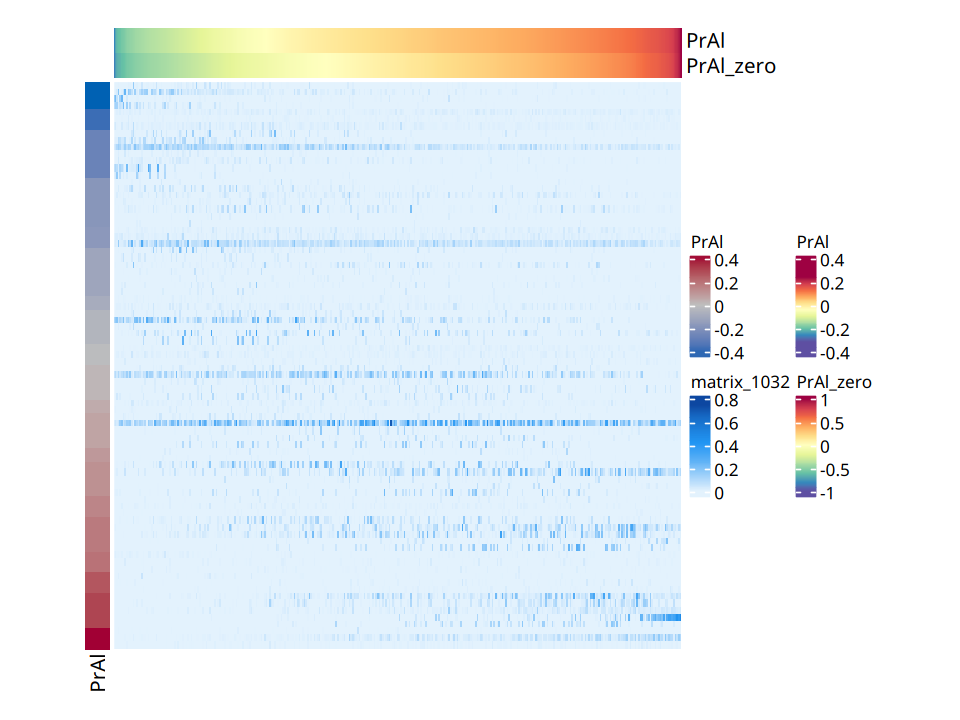

In [926]:
options(repr.plot.width=8,repr.plot.height=6)
color_heatmap <- c("#e3f2fd","#bbdefb","#90caf9","#64b5f6","#42a5f5","#2196f3","#1e88e5","#1976d2","#1565c0","#0d47a1")
obj_tmp <- obj_celltype_all$mous_T313
obj_tmp@assays$celltype@meta.features$celltype <- rownames(obj_tmp)
obj_tmp@assays$celltype@meta.features$PrAl_score <- as.numeric(gsub("minus", "-",gsub(".*-", "",gsub(".*--", "minus", rownames(obj_tmp)))))
obj_tmp$PrAl_celltype <- as.numeric(t(as.matrix(obj_tmp@assays$celltype@meta.features$PrAl_score)) %*% obj_tmp@assays$celltype@data)
obj_tmp@meta.data$PrAl_celltype_zero <- Zero_normalize(obj_tmp@meta.data$PrAl_celltype)-1

Cell_Matrix_sample <- as.matrix(obj_tmp@assays$celltype@data)
PrAl_score <- as.numeric(gsub("minus", "-",gsub(".*-", "",gsub(".*--", "minus", rownames(Cell_Matrix_sample)))))
Cell_Matrix_sample <- Cell_Matrix_sample[order(PrAl_score),]
PrAl_score <- as.numeric(gsub("minus", "-",gsub(".*-", "",gsub(".*--", "minus", rownames(Cell_Matrix_sample)))))
Cell_Matrix_sample <- Cell_Matrix_sample[,order(obj_tmp$PrAl_celltype)]

row_annotation <- rowAnnotation(PrAl = PrAl_score,show_annotation_name = TRUE,show_legend=TRUE,
                                       col=list(
                                       PrAl=colorRamp2(c(min(PrAl_score),0, max(PrAl_score)), c('#0061b3','gray','#a10034'))))
    
col_annotation <- columnAnnotation(PrAl = obj_tmp$PrAl_celltype[order(obj_tmp$PrAl_celltype)],
                                   PrAl_zero = obj_tmp$PrAl_celltype_zero[order(obj_tmp$PrAl_celltype)],
                                   show_annotation_name = TRUE,show_legend=TRUE,
                                       col=list(
                                       PrAl=colorRamp2(seq(min(obj_tmp$PrAl_celltype),max(obj_tmp$PrAl_celltype),length.out = 11), rev(RColorBrewer::brewer.pal(11, "Spectral"))),
                                       PrAl_zero=colorRamp2(seq(-1,1,length.out = 11), rev(RColorBrewer::brewer.pal(11, "Spectral")))))


p <- ComplexHeatmap::Heatmap(Cell_Matrix_sample,cluster_rows = F,cluster_columns = F,show_column_names = F,show_row_names = F,show_heatmap_legend = TRUE,
                           col = color_heatmap,
                        top_annotation = col_annotation,left_annotation=row_annotation,
                        width =ncol(Cell_Matrix_sample)*unit(120/ncol(Cell_Matrix_sample), "mm"),height=nrow(Cell_Matrix_sample)*unit(120/nrow(Cell_Matrix_sample), "mm"),use_raster = TRUE
                       )
p
pdf('Plot/Sample_get_PrAl_Index.pdf',width=8,height=6)
p
dev.off()

In [52]:
obj_axol <- readRDS('Analysis/Region_defined/Gene_axol_delMP.rds')
obj_lung <- readRDS('Analysis/Region_defined/Gene_lung_delMP.rds')
rownames(obj_axol@meta.data) <- paste0(rownames(obj_axol@meta.data),'_8')
rownames(obj_lung@meta.data) <- paste0(rownames(obj_lung@meta.data),'_9')
axol_MP_cell <- rownames(obj_celltype_all_merge@meta.data[obj_celltype_all_merge@meta.data$species=='axol',])[!rownames(obj_celltype_all_merge@meta.data[obj_celltype_all_merge@meta.data$species=='axol',])%in%rownames(obj_axol@meta.data)]
lung_MP_cell <- rownames(obj_celltype_all_merge@meta.data[obj_celltype_all_merge@meta.data$species=='lung',])[!rownames(obj_celltype_all_merge@meta.data[obj_celltype_all_merge@meta.data$species=='lung',])%in%rownames(obj_lung@meta.data)]
obj_celltype_all_merge <- obj_celltype_all_merge[,!rownames(obj_celltype_all_merge@meta.data)%in%c(axol_MP_cell,lung_MP_cell)]
obj_celltype_all_merge@meta.data[obj_celltype_all_merge$species=='axol','region'] <- obj_axol@meta.data[rownames(obj_celltype_all_merge@meta.data[obj_celltype_all_merge$species=='axol',]),'region']
obj_celltype_all_merge@meta.data[obj_celltype_all_merge$species=='lung','region'] <- obj_lung@meta.data[rownames(obj_celltype_all_merge@meta.data[obj_celltype_all_merge$species=='lung',]),'region']

In [1]:
obj_ST_impute <- readRDS('Analysis/obj_ST_gene_all_fishlamp_delMP_impute_norm.rds')

In [8]:
obj_celltype_all_merge <- readRDS('Analysis/obj_ST_celltype_all_delMP.rds')

pdf 
  2

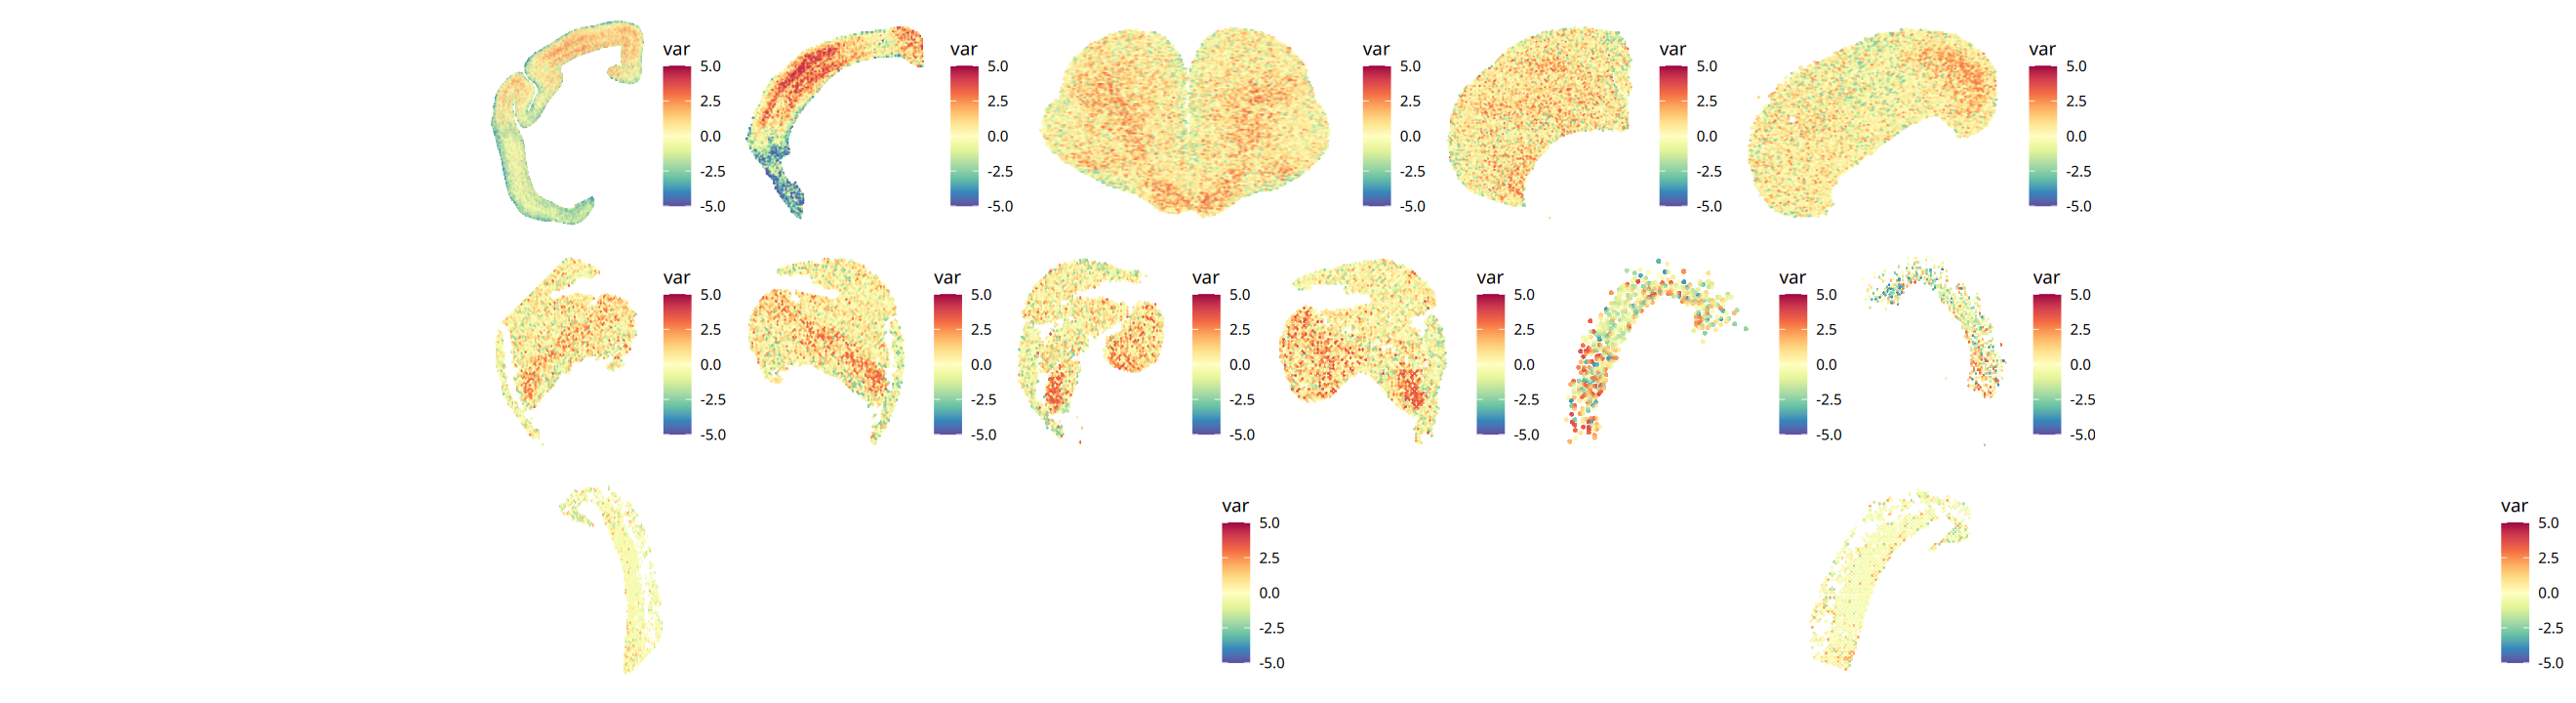

In [23]:
obj_celltype_all_merge@meta.data$var <- obj_celltype_all_merge@meta.data$PrAl_celltype_raw
obj_celltype_all_merge@meta.data[obj_celltype_all_merge@meta.data$var>5,'var'] <- 5
obj_celltype_all_merge@meta.data[obj_celltype_all_merge@meta.data$var< -5,'var'] <- -5
p <- PlotMutiSpeciesSTMeta(obj_celltype_all_merge@meta.data, col_name = 'var',max.cutoff = 0.97,min.cutoff = 0.03,limits = c(-5,5),
                             species=c('marm','mous','bird','turt','axol','lung'),use_color = rev(RColorBrewer::brewer.pal(11, "Spectral")))
options(repr.plot.width=22,repr.plot.height=6)
p
pdf('Plot/All_species_ST_PrAl_Index.pdf',width=22,height=6)
p
dev.off()

In [61]:
saveRDS(obj_celltype_all_merge,'Analysis/RCTD/obj_celltype_all_merge_delMP.rds')

In [2]:
obj_celltype_all_merge <- readRDS('Analysis/RCTD/obj_celltype_all_merge.rds')

In [7]:
use_color <- rev(RColorBrewer::brewer.pal(11, "Spectral"))
var <- 'PrAl_celltype_raw'
for(i in unique(obj_celltype_all_merge$sample)){
    p <- plot_spatial_col(obj_celltype_all_merge@meta.data[obj_celltype_all_merge$sample==i,],col_name = var,smooth = F, size = 3.5,color = use_color)
    save_real_plot(p,dir_path = 'Plot/Region_mask/',name = paste0(i,'_PrAl'),
                   plot_x_vector = obj_celltype_all_merge@meta.data[obj_celltype_all_merge$sample==i,]$x,
                   plot_y_vector = obj_celltype_all_merge@meta.data[obj_celltype_all_merge$sample==i,]$y,edge_add = 50)
    
}

Coordinate system already present. Adding new coordinate system, which will
replace the existing one.
Coordinate system already present. Adding new coordinate system, which will
replace the existing one.
Coordinate system already present. Adding new coordinate system, which will
replace the existing one.
Coordinate system already present. Adding new coordinate system, which will
replace the existing one.
Coordinate system already present. Adding new coordinate system, which will
replace the existing one.
Coordinate system already present. Adding new coordinate system, which will
replace the existing one.
Coordinate system already present. Adding new coordinate system, which will
replace the existing one.
Coordinate system already present. Adding new coordinate system, which will
replace the existing one.
Coordinate system already present. Adding new coordinate system, which will
replace the existing one.


In [53]:
obj_celltype_all_merge$raw_region <- obj_celltype_all_merge$region

In [3]:
source('../R_function/ST_plot.R')
source('../R_function/knn_function.R')

In [54]:
#add bird mask
bird_mask1 <- read_real_mask_plot('Plot/Region_mask/bird_S1_mask_-205.73_-41.08.tif',x_offset = -205.73, y_offset = -41.08)
bird_mask2 <- read_real_mask_plot('Plot/Region_mask/bird_S2_mask_-287.59_-98.79.tif',x_offset = -287.59, y_offset = -98.79)
bird_mask3 <- read_real_mask_plot('Plot/Region_mask/bird_S3_mask_-156.73_-191.17.tif',x_offset = -156.73, y_offset = -191.17)
bird_mask1$region <- c('255'='H','210'='L','205'='E','200'='IH','150'='M','100'='N','125'='LMI','50'='HA','75'='NCL')[as.character(bird_mask1$mask)]
bird_mask2$region <- c('255'='H','210'='L','205'='E','200'='IH','150'='M','100'='N','125'='LMI','50'='HA','75'='NCL')[as.character(bird_mask2$mask)]
bird_mask3$region <- c('255'='H','210'='L','205'='E','200'='IH','150'='M','100'='N','125'='LMI','50'='HA','75'='NCL')[as.character(bird_mask3$mask)]
obj_celltype_all_merge@meta.data[obj_celltype_all_merge$sample=='bird_a1',] <- df_add_mask(obj_celltype_all_merge@meta.data[obj_celltype_all_merge$sample=='bird_a1',],bird_mask1,imputation = T,mask_col = 'region')
obj_celltype_all_merge@meta.data[obj_celltype_all_merge$sample=='bird_d4',] <- df_add_mask(obj_celltype_all_merge@meta.data[obj_celltype_all_merge$sample=='bird_d4',],bird_mask2,imputation = T,mask_col = 'region')
obj_celltype_all_merge@meta.data[obj_celltype_all_merge$sample=='bird_a5',] <- df_add_mask(obj_celltype_all_merge@meta.data[obj_celltype_all_merge$sample=='bird_a5',],bird_mask3,imputation = T,mask_col = 'region')

turt_mask1 <- read_real_mask_plot('Plot/Region_mask/turt_A2_mask_-141.92_49.7.tif',x_offset = -141.92, y_offset = 49.7)
turt_mask2 <- read_real_mask_plot('Plot/Region_mask/turt_F5_mask_-24.54_-92.43.tif',x_offset = -24.54, y_offset = -92.43)
turt_mask1$region <- c('255'='aDVR','200'='LC','150'='lDC','100'='PT','50'='mDC')[as.character(turt_mask1$mask)]
turt_mask2$region <- c('255'='aDVR','200'='LC','150'='lDC','100'='PT','50'='mDC')[as.character(turt_mask2$mask)]
obj_celltype_all_merge@meta.data[obj_celltype_all_merge$sample=='turt_a2',] <- df_add_mask(obj_celltype_all_merge@meta.data[obj_celltype_all_merge$sample=='turt_a2',],turt_mask1,imputation = T,mask_col = 'region')
obj_celltype_all_merge@meta.data[obj_celltype_all_merge$sample=='turt_f5',] <- df_add_mask(obj_celltype_all_merge@meta.data[obj_celltype_all_merge$sample=='turt_f5',],turt_mask2,imputation = T,mask_col = 'region')

mous_mask <- read_real_mask_plot('Plot/Region_mask/mous_T313_mask_-45.11_-170.6.tif',x_offset = -45.11, y_offset = -170.6)
mous_mask$region <- c('255'='PIR','120'='ENT','140'='TE','160'='AU','200'='S1','180'='PP','220'='CG')[as.character(mous_mask$mask)]
obj_celltype_all_merge@meta.data[obj_celltype_all_merge$sample=='mous_T313',] <- df_add_mask(obj_celltype_all_merge@meta.data[obj_celltype_all_merge$sample=='mous_T313',],mous_mask,imputation = F,mask_col = 'region')

marm_region_rename <- c('A1/A2'='S1','A3a'='S1','A3b'='S1','A4ab'='M1','A23a'='CG','A23b'='CG','A23c'='CG','A24d'='CG','A29d'='CG','A30'='CG',
'A35'='TE','A36'='TE','TE1'='TE','TE2'='TE','TE3'='TE','TPO'='TE',
'AuA1'='A1',
'AuAL'='AU','AuCM'='AU','AuCPB'='AU','AuML'='AU','AuR'='AU',
'Ent'='ENT',
'Ipro'='IS','ReI'='IS',
'S2E'='S2','S2I'='S2')
obj_celltype_all_merge@meta.data[obj_celltype_all_merge$sample=='marm_T454','region'] <- marm_region_rename[obj_celltype_all_merge@meta.data[obj_celltype_all_merge$sample=='marm_T454','raw_region']]

In [24]:
obj_celltype_all_merge <- readRDS('Analysis/RCTD/obj_celltype_all_merge.rds')

In [8]:
saveRDS(obj_celltype_all_merge,'Analysis/RCTD/obj_celltype_all_merge.rds')

In [26]:
source('../R_function/ST_plot.R')

In [30]:
p1 <- plot_spatial_col(obj_celltype_all_merge@meta.data[obj_celltype_all_merge$sample=='marm_T454',],col_name = 'region',smooth = F, size = 3.5)+scale_color_manual(values  = pal_igv()(50)[10:50])
p2 <- plot_spatial_col(obj_celltype_all_merge@meta.data[obj_celltype_all_merge$sample=='mous_T313',],col_name = 'region',smooth = F, size = 3.5)+scale_color_manual(values  = pal_igv()(50)[10:50])
pdf('Plot/Region_cluster/Marm_spatial_manual.pdf',width=10,height=10)
p1
dev.off()
pdf('Plot/Region_cluster/Mous_spatial_manual.pdf',width=10,height=10)
p2
dev.off()

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


pdf 
  2

pdf 
  2

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is

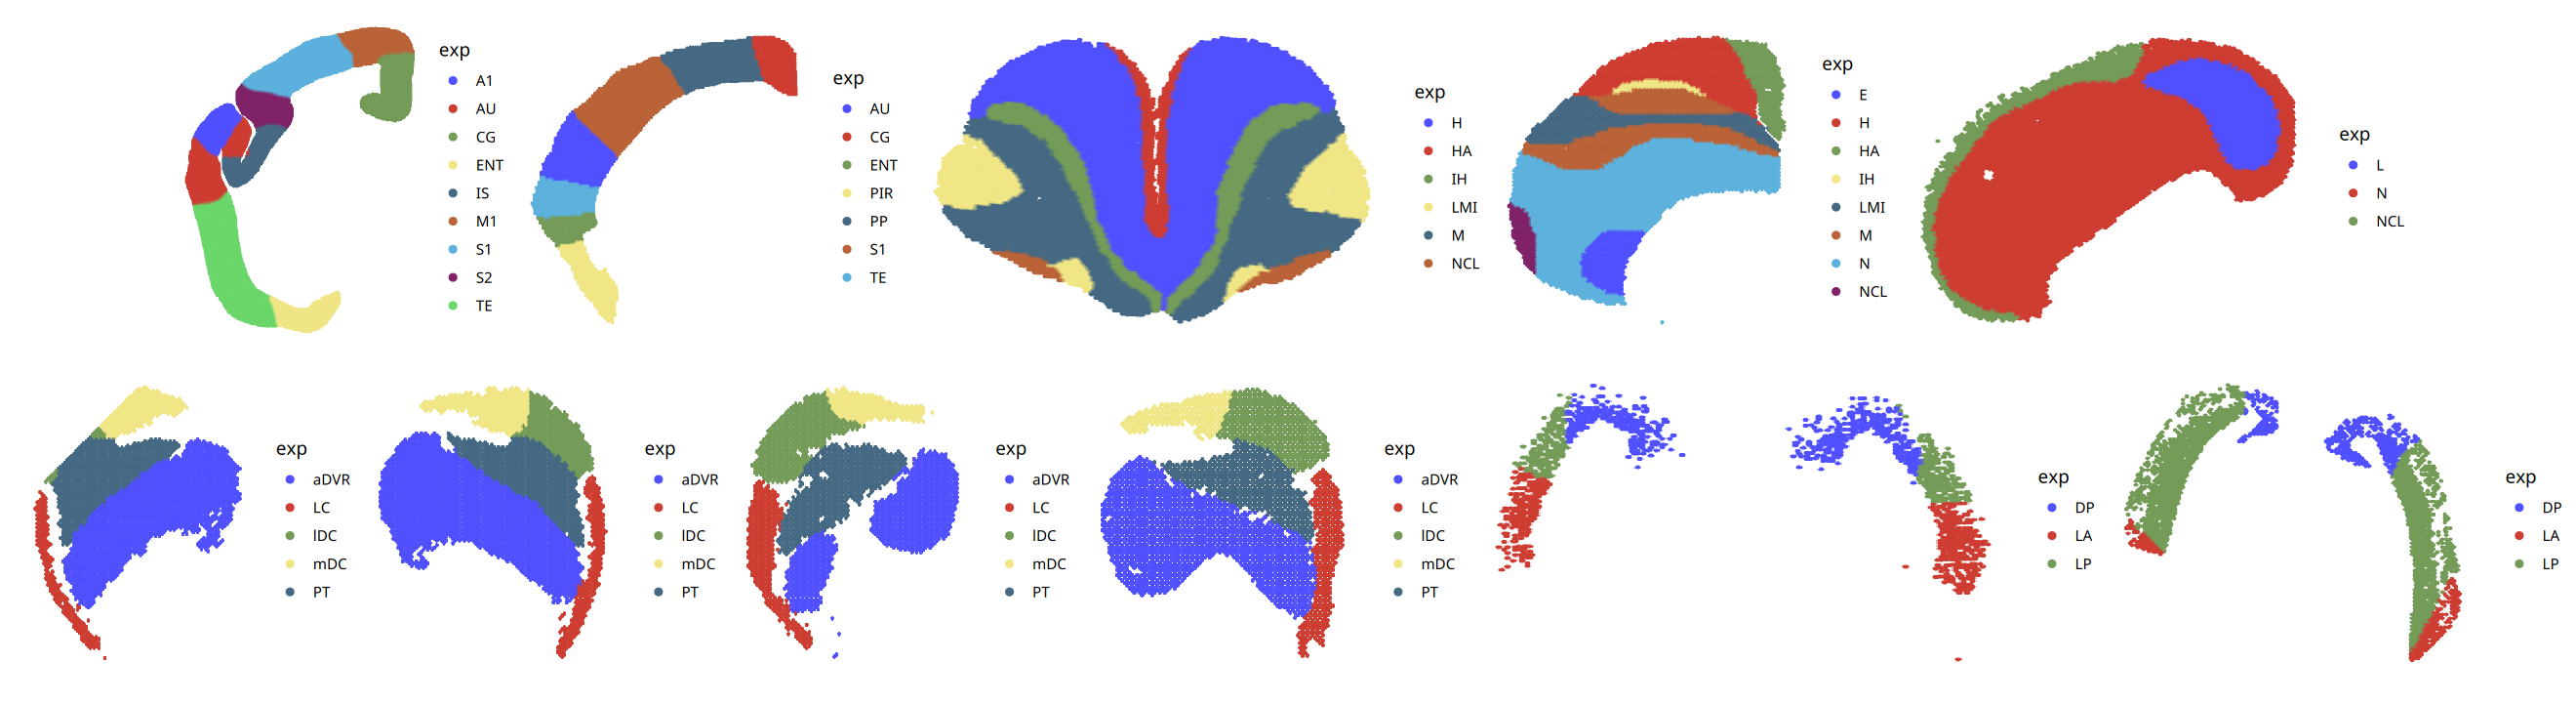

In [47]:
use_color <- rev(RColorBrewer::brewer.pal(11, "Spectral"))
var <- 'region'
p1 <- 
plot_spatial_col(obj_celltype_all_merge@meta.data[obj_celltype_all_merge$sample=='marm_T454',],col_name = var,smooth = F, size = 3.5)+scale_color_manual(values  = pal_igv()(50))+
plot_spatial_col(obj_celltype_all_merge@meta.data[obj_celltype_all_merge$sample=='mous_T313',],col_name = var,smooth = F, size = 3.5)+scale_color_manual(values  = pal_igv()(50))+
plot_spatial_col(obj_celltype_all_merge@meta.data[obj_celltype_all_merge$sample=='bird_a1',],  col_name = var,smooth = F, size = 3.5)+scale_color_manual(values  = pal_igv()(50))+
plot_spatial_col(obj_celltype_all_merge@meta.data[obj_celltype_all_merge$sample=='bird_d4',],  col_name = var,smooth = F, size = 3.5)+scale_color_manual(values  = pal_igv()(50))+
plot_spatial_col(obj_celltype_all_merge@meta.data[obj_celltype_all_merge$sample=='bird_a5',],  col_name = var,smooth = F, size = 3.5)+scale_color_manual(values  = pal_igv()(50))+
plot_layout(ncol = 5)

p2 <- 
plot_spatial_col(obj_celltype_all_merge@meta.data[obj_celltype_all_merge$sample=='turt_a2'&obj_celltype_all_merge$hemisphere=='left',],  col_name = var,smooth = F, size = 4)+scale_color_manual(values  = pal_igv()(50))+
plot_spatial_col(obj_celltype_all_merge@meta.data[obj_celltype_all_merge$sample=='turt_a2'&obj_celltype_all_merge$hemisphere=='right',],  col_name = var,smooth = F, size = 4)+scale_color_manual(values  = pal_igv()(50))+
plot_spatial_col(obj_celltype_all_merge@meta.data[obj_celltype_all_merge$sample=='turt_f5'&obj_celltype_all_merge$hemisphere=='left',],  col_name = var,smooth = F, size = 4)+scale_color_manual(values  = pal_igv()(50))+
plot_spatial_col(obj_celltype_all_merge@meta.data[obj_celltype_all_merge$sample=='turt_f5'&obj_celltype_all_merge$hemisphere=='right',],  col_name = var,smooth = F, size = 4)+scale_color_manual(values  = pal_igv()(50))+
plot_spatial_col(obj_celltype_all_merge@meta.data[obj_celltype_all_merge$sample=='axol_all',], col_name = var,smooth = F, size = 3.5)+scale_color_manual(values  = pal_igv()(50))+
plot_spatial_col(obj_celltype_all_merge@meta.data[obj_celltype_all_merge$sample=='lung_all',], col_name = var,smooth = F, size = 3.5)+scale_color_manual(values  = pal_igv()(50))+
plot_layout(ncol = 6)
options(repr.plot.width=22,repr.plot.height=6)
p1/p2

`summarise()` has grouped output by 'region'. You can override using the
`.groups` argument.


pdf 
  2

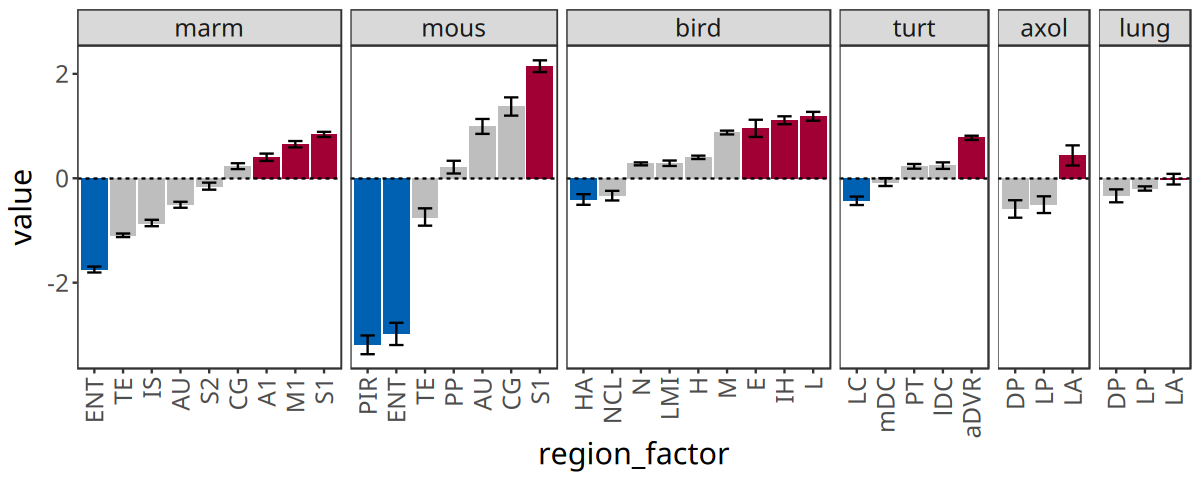

In [59]:
region_mean <- aggregate(list('value'=obj_celltype_all_merge$PrAl_celltype_raw),by=list('region'=paste0(obj_celltype_all_merge$species,'_',obj_celltype_all_merge$region)),mean)
obj_celltype_all_merge@meta.data$species_factor <- factor(obj_celltype_all_merge@meta.data$species,levels = c('marm','mous','bird','turt','axol','lung'))
obj_celltype_all_merge@meta.data$region_factor <- factor(paste0(obj_celltype_all_merge$species,'_',obj_celltype_all_merge$region),levels = region_mean[order(region_mean$value),'region'])

#plot_bar <- aggregate(list('value'=obj_celltype_all_merge$PrAl_celltype_raw),by=list('region'=obj_celltype_all_merge$region,'species'=obj_celltype_all_merge$species),mean)
#plot_bar_sd <- aggregate(list('value'=obj_celltype_all_merge$PrAl_celltype_raw),by=list('region'=obj_celltype_all_merge$region,'species'=obj_celltype_all_merge$species),)
#plot_bar$sd <- plot_bar_sd$value

plot_bar <- obj_celltype_all_merge@meta.data %>%
  group_by(region,species) %>%
  summarise(
    mean = mean(PrAl_celltype_raw),           # 均值
    sd = sd(PrAl_celltype_raw),               # 标准差
    se = sd / sqrt(n()),          # 标准误差
    ci_lower = mean - qnorm(0.975) * se,  # 95% 置信区间下限
    ci_upper = mean + qnorm(0.975) * se   # 95% 置信区间上限
  )
plot_bar <- as.data.frame(plot_bar)
plot_bar$value <- plot_bar$mean
plot_bar$species_factor <- factor(plot_bar$species,levels = c('marm','mous','bird','turt','axol','lung'))
plot_bar$region_factor <- factor(paste0(plot_bar$species,'_',plot_bar$region),levels = paste0(plot_bar[order(plot_bar$value),'species'],'_',plot_bar[order(plot_bar$value),'region']))

region_color <- rep('gray',length(unique(obj_celltype_all_merge@meta.data$region)))
names(region_color) <- unique(obj_celltype_all_merge@meta.data$region)
#region_color <- 'gray'

region_color[names(region_color)%in%c('A1','S1','M1','E','IH','L','aDVR','LA')] <- '#a10034'
region_color[names(region_color)%in%c('Pir','Ent','PIR','ENT','MP','LC','HA','N-Al')] <- '#0061b3'

options(repr.plot.width=10,repr.plot.height=4)
p <- ggplot()+
geom_bar(data=plot_bar,aes(x=region_factor,y=value,fill=region),stat='identity')+
geom_errorbar(data=plot_bar,aes(x=region_factor,ymin=ci_lower,ymax=ci_upper),linewidth=.5,width=.5)+
scale_fill_manual(values  = region_color,breaks = names(region_color))+
geom_hline(yintercept = 0,linetype='dashed')+
ggh4x::facet_grid2(~species_factor, scales = "free", space ="free")+
theme_test()+
theme(text=element_text(size=18),axis.text.x=element_text(angle=90,hjust=1,vjust=0.5))+
scale_x_discrete(
    labels = ~sub("^.*_", "", .x) )+
NoLegend()
p
pdf('Plot/All_species_box_ST_PrAl_Index.pdf',width=10,height=4)
p
dev.off()

In [66]:
saveRDS(obj_celltype_all_merge,'Analysis/obj_ST_celltype_all_delMP.rds')

In [123]:
for(i in unique(obj_celltype_all_merge@meta.data$sample)){
    obj_tmp <- obj_celltype_all_merge[,obj_celltype_all_merge$sample==i]
    species <- gsub('_.*','',i)
    plot_celltype <- rownames(obj_tmp)
    celltype_score <- as.numeric(gsub("minus", "-",gsub(".*-", "",gsub(".*--", "minus", rownames(obj_tmp)))))
    for(j in 1:length(plot_celltype)){
        if(celltype_score[j]>0){
            p <- plot_spatial_feature(obj_tmp,features = plot_celltype[j],col=c('gray','#a10034'),smooth = T, size = 3.5,slot='data',assays = 'celltype')
        }else{
            p <- plot_spatial_feature(obj_tmp,features = plot_celltype[j],col=c('gray','#0061b3'),smooth = T, size = 3.5,slot='data',assays = 'celltype')
        }
        save_png_plot(p,'Plot/celltype_location/',paste0(plot_celltype[j],'-',i),height=800,width=600,save='ggsave')
    }
}

Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; returning the first one. To return all, use `return_all = TRUE`.”


NULL


Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; returning the first one. To return all, use `return_all = TRUE`.”


NULL


Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; returning the first one. To return all, use `return_all = TRUE`.”


...

NULL


Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; returning the first one. To return all, use `return_all = TRUE`.”


NULL


Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; returning the first one. To return all, use `return_all = TRUE`.”


NULL
